In [1]:
%run /home/mrixen/Case_studies/Clean_code/functions/functions.ipynb

### Data processing

In [ ]:
def compute_WCB_ensemble_ascent(resolution_label, pmin=500, pmax=800, data_path='/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/'):
    """
    Loop through all ensemble members, compute WCB ascent/outflow areas,
    and return a list of dicts with time + area data for later plotting.
    """
    file_pattern = os.path.join(data_path, f'trajectories_{resolution_label}_ens*remapcon.nc')
    file_list = sorted(glob.glob(file_pattern))
    print(file_list)
    
    all_results = []  # store (time, area_ascent, area_outflow, ens_name)
    
    for f in file_list:
        ens_name = os.path.basename(f).split('_')[-1].replace('.nc', '')
        print(f'Processing {ens_name}...')

        ds = xr.open_dataset(f)
        ds_WCB = select_WCB_trajectories_pressure_end_point(ds)

        mask_ascent = compute_WCB_mask(ds_WCB, pmin=pmin, pmax=pmax)

        area_ascent = compute_mask_area(mask_ascent)

        all_results.append({
            'ens': ens_name,
            'time': mask_ascent.time_abs.values,
            'area_ascent': area_ascent
        })
    
    return all_results

In [22]:
#results_R02B07 = compute_WCB_ensemble_ascent('R02B07')
#results_R02B08 = compute_WCB_ensemble_ascent('R02B08')
#results_R02B08_no_conv = compute_WCB_ensemble_ascent('R02B08_no_conv')
#results_R02B09 = compute_WCB_ensemble_ascent('R02B09')
#results_R02B10 = compute_WCB_ensemble_ascent('R02B10')

['/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens0.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens1.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens2.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens3.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens4.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens5.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens6.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens7.nc', '/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B09_ens8.nc', '/highres_nobackup/mrixen/simulation

In [23]:
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B07_remapcon.pkl', 'wb') as f:
    pickle.dump(results_R02B07, f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B08_remapcon.pkl', 'wb') as f:
    pickle.dump(results_R02B08, f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B08_no_conv_remapcon.pkl', 'wb') as f:
    pickle.dump(results_R02B08_no_conv, f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B09_remapcon.pkl', 'wb') as f:
    pickle.dump(results_R02B09, f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B10_remapcon.pkl', 'wb') as f:
    pickle.dump(results_R02B10, f)

### Plotting

In [2]:
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B07_remapcon.pkl', 'rb') as f:
    results_R02B07 = pickle.load(f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B08_remapcon.pkl', 'rb') as f:
    results_R02B08 = pickle.load(f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B08_no_conv_remapcon.pkl', 'rb') as f:
    results_R02B08_no_conv = pickle.load(f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B09_remapcon.pkl', 'rb') as f:
    results_R02B09 = pickle.load(f)
with open('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/results_R02B10_remapcon.pkl', 'rb') as f:
    results_R02B10 = pickle.load(f)

In [3]:
# Load first dataset
ds_era = xr.open_dataset('/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/trajectories_ERA5_combined.nc')
ds_era_WCB = select_WCB_trajectories_pressure_end_point(ds_era)
mask_da_era_ascent = compute_WCB_mask(ds_era_WCB, pmin=500, pmax=800)
mask_da_era_outflow = compute_WCB_mask(ds_era_WCB, pmin=100, pmax=400)
area_era_ascent = compute_mask_area(mask_da_era_ascent)
area_era_outflow= compute_mask_area(mask_da_era_outflow)

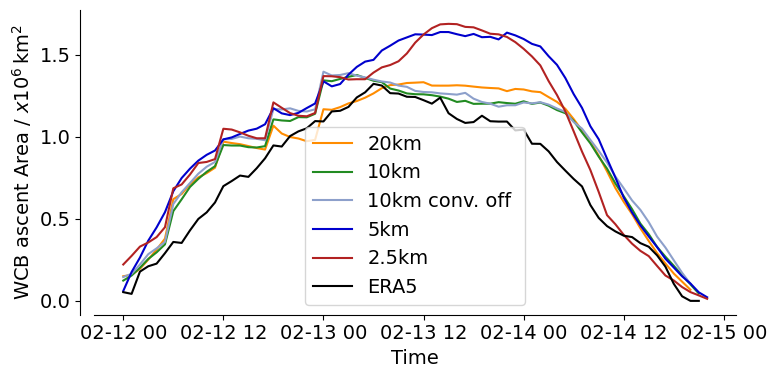

In [4]:
plt.figure(figsize=(8, 4))

# Plot individual members for all four resolutions
#for res, color in zip(
#    [results_R02B07, results_R02B08, results_R02B08_no_conv, results_R02B09, results_R02B10],
#    ['red', 'orange', '#8da0cb', 'mediumblue', 'firebrick']):
    #for r in res:
        #plt.plot(r['time'], r['area_ascent'], color=color, alpha=0.05)

# --- Compute ensemble means ---
def ensemble_mean(results):
    min_len = min(len(r['area_ascent']) for r in results)
    time = results[0]['time'][:min_len]
    areas = np.stack([r['area_ascent'][:min_len] for r in results])
    return time, areas.mean(axis=0)

time07, mean07 = ensemble_mean(results_R02B07)
time08, mean08 = ensemble_mean(results_R02B08)
time08nc, mean08nc = ensemble_mean(results_R02B08_no_conv)
time09, mean09 = ensemble_mean(results_R02B09)
time10, mean10 = ensemble_mean(results_R02B10)

# --- Plot ensemble means ---
plt.plot(time07, mean07, color='darkorange', label='20km', linewidth=1.5)
plt.plot(time08, mean08, color='forestgreen', label='10km', linewidth=1.5)
plt.plot(time08nc, mean08nc, color='#8da0cb', label='10km conv. off ', linewidth=1.5)
plt.plot(time09, mean09, color='mediumblue', label='5km', linewidth=1.5)
plt.plot(time10, mean10, color='firebrick', label='2.5km', linewidth=1.5)

# Optional ERA5 reference
plt.plot(mask_da_era_ascent.time_abs.values, area_era_ascent, 
         color='k', label='ERA5', linewidth=1.5)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_position(("outward", 10))

plt.xlabel('Time')
plt.ylabel(r'WCB ascent Area / $x 10^{6}\, \rm km^2$')
#plt.title('WCB Ascent Area accross resolutions')
plt.legend()
#plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(
    "../Figures/Dennis_ascent_area_WCB.pdf", 
    dpi=300, 
    bbox_inches="tight"
)
plt.show()

In [5]:
start_era = '2020-02-08T00'
end_era = '2020-02-25T00'
ds_era_geo = load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='H',
)

ERA5_30D_mean_climatology = xr.open_dataset('/home/mrixen/Case_studies/Clean_code/data/3D_running_mean_era5_Z500_2.nc')['Z'].isel(plev=0).sel(lat=slice(20,80), lon = slice(-100,45))/9.81
z500_era = ds_era_geo.Z.sel(plev=50000).sel(lat=slice(20,80), lon = slice(-100,45))  /9.81

In [6]:
ds_era_WCB = select_WCB_trajectories_pressure_end_point(ds_era)

# Compute pressure change per hour: Δp / Δt
# pressure in hPa, time in hours
pressure = ds_era_WCB["pressure"]  # shape: (trajectory, time)
time_diff = np.diff(ds_era_WCB["time"].values) #/ np.timedelta64(1, "s")  # in seconds
#time_diff = time_diff / 3600.0  # convert seconds → hours

# Δp along time axis
dp = np.diff(pressure, axis=1)
# Divide by Δt to get hPa/h
p_rate = -dp / time_diff  # negative because decreasing pressure = ascent

# Flatten to 1D across trajectories and time
p_rate_all = p_rate.ravel()
p_rate_all = p_rate_all[np.isfinite(p_rate_all)]

p_rate_99_val_era = np.quantile(p_rate_all, 0.998)  # 99th percentile

In [7]:
ds_era_WCB = select_WCB_trajectories_pressure_end_point(ds_era)

# Compute pressure change per hour: Δp / Δt
# pressure in hPa, time in hours
pressure = ds_era_WCB["pressure"]  # shape: (trajectory, time)
time_diff = np.diff(ds_era_WCB["time"].values) #/ np.timedelta64(1, "s")  # in seconds
#time_diff = time_diff / 3600.0  # convert seconds → hours

# Δp along time axis
dp = np.diff(pressure, axis=1)
# Divide by Δt to get hPa/h
p_rate = -dp / time_diff  # negative because decreasing pressure = ascent

# Flatten to 1D across trajectories and time
p_rate_all = p_rate.ravel()
p_rate_all = p_rate_all[np.isfinite(p_rate_all)]

p_rate_99_val_era = np.quantile(p_rate_all, 0.95)  # 95th percentile

In [ ]:
base_path = "/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble"

p_rate_99 = {}

p_rate_99["R02B07"] = compute_p_rate_99_for_resolution("R02B07", base_path)
p_rate_99["R02B08"] = compute_p_rate_99_for_resolution("R02B08", base_path)
p_rate_99["R02B08_no_conv"] = compute_p_rate_99_for_resolution("R02B08_no_conv", base_path)
p_rate_99["R02B09"] = compute_p_rate_99_for_resolution("R02B09", base_path)
p_rate_99["R02B10"] = compute_p_rate_99_for_resolution("R02B10", base_path)

/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens001_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens002_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens003_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens004_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens005_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens006_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens007_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/trajectories_R02B07_ens008_remapcon.nc
/highres_nobackup/mrixen/simulations/Dennis_v1/Lagranto_all/output/ensemble/traj

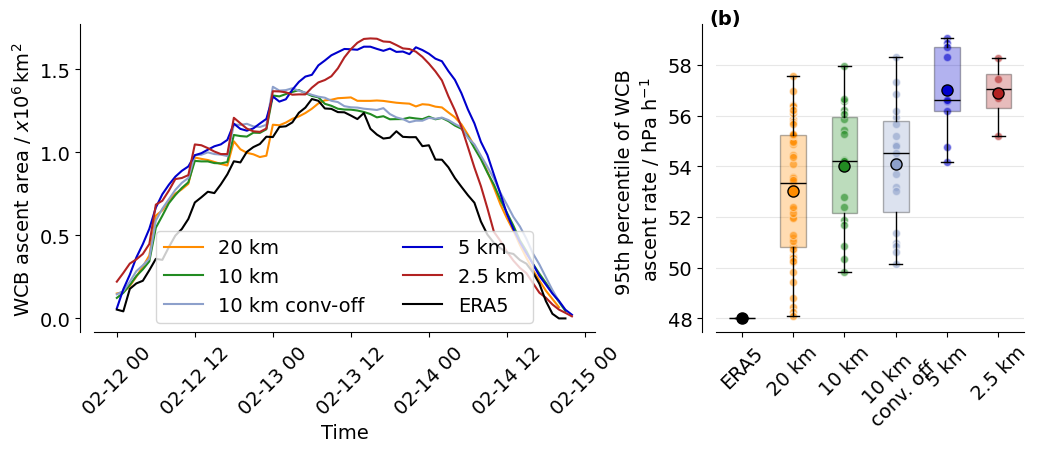

In [11]:
# --- Define colors for consistency ---
colors_left = {
    "40 km": "purple",          
    "20 km": "darkorange",          
    "10 km": "forestgreen",         
    "10 km conv-off": "#8da0cb",    
    "5 km": "mediumblue",           
    "2.5 km": "firebrick",           
    "ERA": "k"
}

labels_order = ["20 km", "10 km", "10 km conv-off", "5 km", "2.5 km"]

# --- Figure setup ---
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[1.3, .8], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])  # Left: time series
ax2 = fig.add_subplot(gs[0, 1])  # Right: boxplot

# -----------------------------
# LEFT PANEL: WCB ascent area
# -----------------------------
plt_data = [
    (time07, mean07, "20 km"),
    (time08, mean08, "10 km"),
    (time08nc, mean08nc, "10 km conv-off"),
    (time09, mean09, "5 km"),
    (time10, mean10, "2.5 km"),
]

for t, m, label in plt_data:
    ax1.plot(t, m, color=colors_left[label], label=label, linewidth=1.5)

# ERA5 reference
ax1.plot(
    mask_da_era_ascent.time_abs.values,
    area_era_ascent,
    color=colors_left["ERA"],
    linewidth=1.5,
    label="ERA5"
)

ax1.set_xlabel("Time")
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel(r'WCB ascent area / $x 10^{6}\, \rm km^2$')
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_position(("outward", 10))
ax1.legend(ncols=2)

# -----------------------------
# RIGHT PANEL: Boxplot
# -----------------------------
colors = {
    "ERA": "black",
    "R02B07": "darkorange",
    "R02B08": "forestgreen",
    "R02B08_no_conv": "#8da0cb",
    "R02B09": "mediumblue",
    "R02B10": "firebrick",
}

resolutions = ["ERA", "R02B07", "R02B08", "R02B08_no_conv", "R02B09", "R02B10"]
labels = ["ERA5", "20 km", "10 km", "10 km\nconv. off", "5 km", "2.5 km"]

x_positions = np.arange(len(resolutions))

# --- Collect data ---
data_p_rate = []

# ERA (single value)
data_p_rate.append([p_rate_99_val_era])

# ICON resolutions
for res in resolutions[1:]:
    vals = [v for v in p_rate_99[res].values() if np.isfinite(v)]
    data_p_rate.append(vals)

# Clear axis
ax2.cla()

# --- Scatter points ---
for i, vals in enumerate(data_p_rate):
    ax2.scatter(
        [x_positions[i]] * len(vals),
        vals,
        color=colors[resolutions[i]],
        alpha=0.6,
        zorder=2,
        edgecolor='white'
    )

# --- Boxplot ---
bp = ax2.boxplot(
    data_p_rate,
    positions=x_positions,
    widths=0.5,
    patch_artist=True,
    showmeans=True,
    medianprops=dict(color="black"),
    meanprops=dict(marker="o", markersize=8, markeredgewidth=1.5)
)

# --- Styling boxes ---
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[resolutions[i]])
    patch.set_alpha(0.3)

    mean_marker = bp['means'][i]
    mean_marker.set_markerfacecolor(colors[resolutions[i]])
    mean_marker.set_markeredgecolor('black')
    mean_marker.set_markeredgewidth(1)
    mean_marker.set_markersize(8)

# --- Axes formatting ---
ax2.set_xlim(-0.5, len(resolutions)-0.5)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(labels, rotation=45)
ax2.set_ylabel("95th percentile of WCB \nascent rate / hPa h$^{-1}$")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_position(("outward", 10))
ax2.grid(axis="y", alpha=0.3)

# Panel label
ax2.text(-0.02, 1.05, "(b)", transform=ax2.transAxes,
         va='top', ha='left', fontweight="bold")

# --- Final layout ---
plt.tight_layout()
plt.savefig("../Figures/Dennis_combined_WCB.pdf", dpi=300, bbox_inches="tight")
plt.show()